# Practice 05: PageRank на реальных данных с GraphBLAS

## Курс: Высокопроизводительный анализ графовых данных
**Тема:** Масштабируемый PageRank с использованием GraphBLAS

## Цели занятия:
1. Закрепить понимание алгоритма PageRank и его математической основы
2. Научиться работать с реальными графовыми данными (SNAP, Network Repository)
3. Реализовать оптимизированные версии PageRank:
   - С обработкой висячих узлов (dangling nodes)
   - Персонализированный PageRank
   - Инкрементальный PageRank
4. Проанализировать сходимость и производительность
5. Визуализировать результаты ранжирования

# Эволюция PageRank: от классики к высокопроизводительным реализациям

Алгоритм **PageRank** — это не одна формула, а семейство методов ранжирования вершин ориентированного графа, основанных на модели случайного блуждания с телепортацией. В зависимости от структуры данных, требований к памяти и бизнес-задачи выбирают конкретную версию. Ниже разобраны все основные варианты, их математическая суть и ключевые отличия.

---

## 🔹 1. Классический PageRank (Basic PageRank)
**Суть:** Изначальная формулировка от Larry Page и Sergey Brin (1998). Моделирует серфера, который с вероятностью $\beta$ переходит по случайной ссылке, а с вероятностью $1-\beta$ "телепортируется" на случайную страницу.

**Математика:**
$$r = \beta M^\top r + \frac{1-\beta}{N} \mathbf{1}$$
где:
- $M_{ij} = 1/d_{\text{out}}(i)$, если есть ребро $i \to j$ (стохастическая матрица)
- $N$ — число вершин, $\beta \in (0,1)$ — коэффициент демпфирования (обычно $0.85$)
- $\mathbf{1}$ — вектор из единиц

**Как работает:** Итерационный метод (Power Iteration). На каждом шаге вектор рангов умножается на транспонированную матрицу переходов. Сходимость гарантирована теоремой Перрона-Фробениуса.

**Проблема:** Если в графе есть **висячие узлы** (dangling nodes) без исходящих рёбер, масса ранга "утекает", и сумма компонент $r$ перестаёт равняться $1$. Алгоритм перестаёт быть стохастическим.

---

## 🔹 2. PageRank с обработкой висячих узлов (Dangling-Aware PR)
**Суть:** Явное сохранение вероятностной массы. Ранги висячих узлов не исчезают, а равномерно распределяются по всем вершинам на каждом шаге.

**Математика:**
$$r = \beta \left( M^\top r + \frac{d_{\text{dang}}^\top r}{N} \mathbf{1} \right) + \frac{1-\beta}{N} \mathbf{1}$$
где $d_{\text{dang}}$ — индикаторный вектор висячих узлов ($1$ если $d_{\text{out}}=0$, иначе $0$).

**Отличие от классики:** На каждой итерации вычисляется скаляр `dangling_mass = sum(r[i] for i in dangling)`, который добавляется к телепортации. В `graphblas` это реализуется через маски и скалярные операции без изменения структуры матрицы.

**Когда использовать:** Любой реальный граф (веб, соцсети, цитирования). Без этого шага результаты на реальных данных **некорректны**.

---

## 🔹 3. Персонализированный PageRank (PPR)
**Суть:** Вместо равномерной телепортации $\frac{1-\beta}{N}\mathbf{1}$ используется заданный вектор предпочтений $v$. Сумма компонент $v$ равна $1$.

**Математика:**
$$r = \beta M^\top r + (1-\beta) v + \beta \frac{d_{\text{dang}}^\top r}{N} \mathbf{1}$$

**Отличие:**
- Если $v = \frac{1}{N}\mathbf{1}$, получаем обычный PageRank.
- Если $v = e_k$ (единица только в узле $k$), получаем **локальный PageRank**, ранжирующий узлы по близости к $k$.
- Сходится быстрее, если $v$ разреженный, так как масса концентрируется в локальной окрестности.

**Применение:** Поиск "ближайших" узлов, рекомендации друзей, локальный анализ сообществ, ранжирование в личном кабинете пользователя.

---

## 🔹 4. Динамический (инкрементальный) PageRank
**Суть:** При добавлении/удалении рёбер или вершин не нужно пересчитывать всё с нуля. Используется линеаризация уравнения вокруг стационарного решения $r_{\text{old}}$.

**Математика (приближённо):**
$$\Delta r \approx \beta M^\top \Delta r + \beta \Delta M^\top r_{\text{old}}$$
где $\Delta M$ — изменение матрицы переходов после модификации графа.

**Отличие:**
- Полная пересчёт: $O(k \cdot |E|)$ на каждой итерации.
- Инкрементальный: $O(k \cdot |\Delta E| + |\text{затронутые вершины}|)$.
- Даёт приближённый результат, но при малых изменениях графа погрешность экспоненциально мала.

**Применение:** Потоковые графы, live-аналитика соцсетей, обновление индекса поисковика без полной переиндексации.

---

## 🔹 5. Тематический PageRank (Topic/Cluster PR)
**Суть:** Объединяет кластеризацию графа и PPR. Для каждого кластера $C$ строится свой вектор персонализации:
$$v_C[i] = \begin{cases} 1/|C|, & i \in C \\ 0, & i \notin C \end{cases}$$

**Отличие:**
- Вместо одного глобального ранга получаем **набор рангов** по темам.
- Узел может иметь высокий ранг в кластере "Спорт", но низкий в "Наука".
- Позволяет строить рекомендации с объяснением: *"Рекомендуем узел X, так как он сильно связан с вашим интересом C"*.

**Применение:** Персонализированные новостные ленты, рекомендательные системы, анализ интересов пользователей.

---

## 🔹 6. Вычислительные варианты (GraphBLAS-ориентированные)
Эти версии не меняют математику, а оптимизируют **как** она выполняется на разреженных матрицах.

| Подход | Суть | Когда эффективен |
|--------|------|------------------|
| **Pull-формализм** | $w = M^\top (t \oslash d_{\text{out}})$ | Стандарт для GraphBLAS. Эффективен, когда $d_{\text{out}}$ не слишком разрежена. |
| **Push-формализм** | $r \leftarrow r + \text{scatter}(t_i / d_{\text{out}}(i), \text{nbrs}(i))$ | Лучше, когда много висячих узлов или граф сильно асимметричен. |
| **FP32 vs FP64** | Замена `dtypes.FP64` на `FP32` | Графы >10M узлов. Ускоряет в 1.5–2x, погрешность $<10^{-4}$ (приемлемо для ранжирования). |
| **Блочная обработка** | `gb.Matrix.ss.split()` или ручное разбиение | Когда матрица не помещается в RAM. Позволяет считать графы >100M узлов на одной машине. |
| **Топ-$k$ аппроксимация** | Остановка, когда $\|r^{(t)} - r^{(t-1)}\|_1 < \varepsilon$ только для top-$k$ | Когда нужны только лидеры, а не точные значения для всех узлов. |

---

## 📊 Сравнительная таблица

| Версия | Формула телепортации | Сложность итерации | Точность | Когда применять |
|--------|----------------------|-------------------|----------|-----------------|
| Классический | $\frac{1-\beta}{N}\mathbf{1}$ | $O(|E|)$ | ❌ На реальных графах расходится | Только учебные примеры |
| С dangling | $\frac{1-\beta + \beta \cdot m_{\text{dang}}}{N}\mathbf{1}$ | $O(|E|)$ | ✅ Строго стохастический | Базовая реализация |
| Персонализированный (PPR) | $(1-\beta)v + \dots$ | $O(|E|)$ | ✅ Зависит от разреженности $v$ | Локальный поиск, рекомендации |
| Динамический | $\Delta r \approx \beta M^\top \Delta r + \beta \Delta M^\top r_{\text{old}}$ | $O(|\Delta E| \cdot k)$ | ⚠️ Приближённый | Потоковые данные, инкрементальные обновления |
| Тематический | Набор $\{v_C\}$ | $O(C \cdot |E|)$ | ✅ По кластерам | Контент-рекомендации, сегментация |
| GraphBLAS-оптимизированный | Та же, но через маски/FP32/блоки | $O(|E|/p)$ на $p$ потоков | ✅ Контролируемая точность | Большие графы, production |

---

Понимание этих деталей отличает "академический" PageRank от **высокопроизводительного**, способного обрабатывать графы с миллиардами рёбер на обычном железе.

In [1]:
!pip install python-graphblas networkx matplotlib pandas numpy
!pip install graphviz

In [2]:
import os
os.environ.setdefault("GRAPHBLAS_BACKEND", "suitesparse")

import graphblas as gb
from graphblas import Matrix, Vector, dtypes, unary, binary, monoid, semiring
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
import warnings
import urllib.request
import gzip
from pathlib import Path

warnings.filterwarnings('ignore')

print("GraphBLAS успешно импортирован. Автоматическая инициализация активна.")

GraphBLAS успешно импортирован. Автоматическая инициализация активна.


## Часть 1: Математическая основа PageRank

Алгоритм PageRank описывается уравнением:

$$r = \beta \cdot M^T r + \frac{1-\beta}{N} \cdot \mathbf{1}$$

где:
- $M_{ij} = 1/d_{out}(i)$ если есть ребро $i \to j$ (стохастическая матрица)
- $\beta$ — коэффициент демпфирования (обычно 0.85)
- $N$ — количество вершин
- $r$ — вектор рангов (стационарное распределение)

In [3]:
def create_stochastic_matrix(A):
    """
    Преобразует бинарную матрицу смежности в стохастическую матрицу M.
    Гарантирует, что каждая строка i суммируется в 1 (если d_out[i] > 0).
    """
    n = A.nrows
    d_out = A.reduce_rowwise(monoid.plus).new()

    inv_d = Vector(dtypes.FP64, n)
    mask = (d_out > 0).new()
    inv_d(mask=mask.S) << binary.truediv(1.0, d_out)

    # Создаём диагональную матрицу D[i,i] = 1/d_out[i]
    D = Matrix.diag(inv_d)
    # Умножение D @ A масштабирует СТРОКИ: M[i,j] = D[i,i] * A[i,j]
    M = D @ A

    return M, d_out

In [4]:
def pagerank_basic(A, damping=0.85, max_iter=100, tol=1e-6, verbose=False):
    n = A.nrows
    teleport = (1 - damping) / n
    M, d_out = create_stochastic_matrix(A)

    r = Vector(dtypes.FP64, n)
    r[:] << 1.0 / n
    t = Vector(dtypes.FP64, n)
    w = Vector(dtypes.FP64, n)

    history = {'rdiff': [], 'time_per_iter': []}

    for iteration in range(max_iter):
        start_time = time.time()
        t << r
        w << M.T.mxv(t, semiring.plus_times)
        r << binary.times(damping, w)
        r(binary.plus)[:] << teleport

        diff = t.ewise_mult(r, binary.minus).apply(unary.abs)
        rdiff = diff.reduce(monoid.plus).new().value

        iter_time = time.time() - start_time
        history['rdiff'].append(rdiff)
        history['time_per_iter'].append(iter_time)

        if verbose and iteration % 10 == 0:
            print(f"Iter {iteration:3d}: rdiff={rdiff:.2e}, time={iter_time*1000:.2f}ms")

        if rdiff < tol:
            if verbose: print(f"✓ Сходимость достигнута на итерации {iteration+1}")
            break

    return r, history

### Тест на синтетическом графе

In [5]:
# Создаём небольшой тестовый граф для проверки
A_test = Matrix.from_coo(
    [0, 0, 1, 2, 2, 3, 4],          # rows
    [1, 2, 3, 3, 4, 4, 0],          # columns
    [1]*7,                          # values
    dtype=dtypes.UINT8
)

print("Тестовый граф (матрица смежности):")
print(A_test)

Тестовый граф (матрица смежности):
"M_0"      nvals  nrows  ncols  dtype         format
gb.Matrix      7      5      5  UINT8  bitmapr (iso)
----------------------------------------------------
   0  1  2  3  4
0     1  1      
1           1   
2           1  1
3              1
4  1            


Iter   0: rdiff=3.40e-01, time=8.20ms
Iter  10: rdiff=3.22e-02, time=0.43ms
Iter  20: rdiff=3.13e-03, time=0.48ms
Iter  30: rdiff=3.48e-04, time=0.49ms
Iter  40: rdiff=3.60e-05, time=5.75ms
Iter  50: rdiff=3.44e-06, time=0.46ms
✓ Сходимость достигнута на итерации 57

Результаты PageRank:
  Node 0: 0.254192
  Node 1: 0.138032
  Node 2: 0.138032
  Node 3: 0.205990
  Node 4: 0.263755


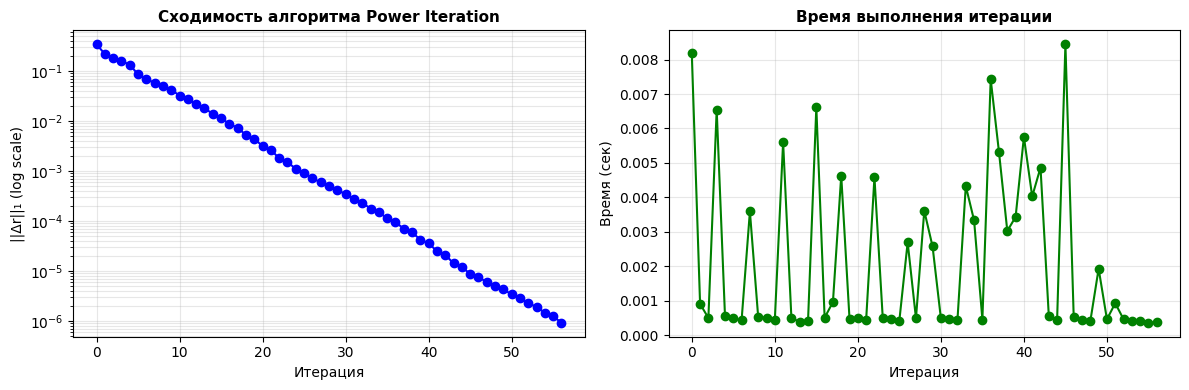

In [6]:
# Запускаем базовый PageRank на тестовом графе
r_test, hist_test = pagerank_basic(A_test, verbose=True)

print("\n" + "="*50)
print("Результаты PageRank:")
print("="*50)
for i in range(A_test.nrows):
    print(f"  Node {i}: {r_test[i].value:.6f}")

# Визуализация сходимости
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.semilogy(hist_test['rdiff'], 'b-o', linewidth=1.5)
plt.xlabel('Итерация', fontsize=10)
plt.ylabel('||Δr||₁ (log scale)', fontsize=10)
plt.title('Сходимость алгоритма Power Iteration', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')

plt.subplot(1, 2, 2)
plt.plot(hist_test['time_per_iter'], 'g-o', linewidth=1.5)
plt.xlabel('Итерация', fontsize=10)
plt.ylabel('Время (сек)', fontsize=10)
plt.title('Время выполнения итерации', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Часть 2: Работа с реальными данными из SNAP

In [7]:
def load_snap_dataset(dataset_name, cache_dir='./snap_datasets'):
    """
    Загружает граф из коллекции SNAP (Stanford Network Analysis Project)

    Parameters:
    -----------
    dataset_name : str - имя датасета (например, 'ego-facebook', 'wiki-Vote')
    cache_dir : str - директория для кэширования загруженных файлов

    Returns:
    --------
    A : gb.Matrix - матрица смежности в формате GraphBLAS
    meta : dict - метаданные графа (количество узлов, рёбер, плотность)
    """
    # Каталог для кэширования датасетов
    cache_path = Path(cache_dir)
    cache_path.mkdir(exist_ok=True)

    # URL для популярных датасетов SNAP
    snap_urls = {
        'ego-facebook': 'https://snap.stanford.edu/data/facebook_combined.txt.gz',
        'wiki-Vote': 'https://snap.stanford.edu/data/wiki-Vote.txt.gz',
        'web-Stanford': 'https://snap.stanford.edu/data/web-Stanford.txt.gz',
        'soc-epinions1': 'https://snap.stanford.edu/data/soc-Epinions1.txt.gz',
    }

    if dataset_name not in snap_urls:
        print(f"Датасет '{dataset_name}' не найден в предустановленных.")
        print(f"Доступные датасеты: {list(snap_urls.keys())}")
        return None, None

    # Скачивание и распаковка файла
    url = snap_urls[dataset_name]
    filename = url.split('/')[-1]
    filepath = cache_path / filename
    txt_path = cache_path / filename.replace('.gz', '')

    if not txt_path.exists():
        print(f"Загрузка {dataset_name}...")
        if not filepath.exists():
            urllib.request.urlretrieve(url, filepath)
        with gzip.open(filepath, 'rt') as f_in:
            with open(txt_path, 'w') as f_out:
                for line in f_in:
                    if not line.startswith('#') and line.strip():
                        f_out.write(line)

    # Чтение графа через NetworkX для удобства парсинга
    print(f"Чтение графа из {txt_path.name}...")
    G = nx.read_edgelist(txt_path, create_using=nx.DiGraph())

    # Преобразование в формат GraphBLAS
    print("Конвертация в формат GraphBLAS...")
    A = gb.io.from_networkx(G, dtype=dtypes.UINT8)

    # Сбор метаданных
    meta = {
        'name': dataset_name,
        'n_nodes': A.nrows,
        'n_edges': A.nvals,
        'density': A.nvals / (A.nrows * A.ncols) if A.nrows > 0 else 0,
        'source': 'SNAP'
    }

    print(f"Загружено: {meta['n_nodes']:,} узлов, {meta['n_edges']:,} рёбер")
    print(f"   Плотность графа: {meta['density']:.2e}")

    return A, meta

### Для больших графов может потребоваться много памяти!

Начнём с небольшого датасета для демонстрации:

In [8]:
# Загружаем небольшой граф для демонстрации: ego-facebook (~4K узлов)
A_fb, meta_fb = load_snap_dataset('ego-facebook')

if A_fb is not None:
    print(f"\n{'='*60}")
    print(f"Статистика графа '{meta_fb['name']}':")
    print(f"{'='*60}")
    print(f"  Узлы: {meta_fb['n_nodes']:,}")
    print(f"  Рёбра: {meta_fb['n_edges']:,}")
    print(f"  Средняя степень: {meta_fb['n_edges']/meta_fb['n_nodes']:.2f}")
    print(f"  Плотность: {meta_fb['density']:.2e}")

    # Анализ распределения степеней вершин
    d_out = A_fb.reduce_rowwise(monoid.plus).new()
    d_in = A_fb.reduce_columnwise(monoid.plus).new()

    print(f"\nРаспределение степеней:")
    print(f"  Исходящие: min={d_out.reduce(monoid.min).new().value}, "
          f"max={d_out.reduce(monoid.max).new().value}, "
          f"mean={d_out.reduce(monoid.plus).new().value/meta_fb['n_nodes']:.2f}")
    print(f"  Входящие:  min={d_in.reduce(monoid.min).new().value}, "
          f"max={d_in.reduce(monoid.max).new().value}, "
          f"mean={d_in.reduce(monoid.plus).new().value/meta_fb['n_nodes']:.2f}")

Чтение графа из facebook_combined.txt...
Конвертация в формат GraphBLAS...
Загружено: 4,039 узлов, 88,234 рёбер
   Плотность графа: 5.41e-03

Статистика графа 'ego-facebook':
  Узлы: 4,039
  Рёбра: 88,234
  Средняя степень: 21.85
  Плотность: 5.41e-03

Распределение степеней:
  Исходящие: min=1, max=236, mean=0.04
  Входящие:  min=1, max=251, mean=0.04


## Часть 3: Оптимизированная реализация с обработкой висячих узлов

In [9]:
def pagerank_with_dangling(A, damping=0.85, max_iter=100, tol=1e-6, verbose=False):
    n = A.nrows
    # Гарантируем бинарную матрицу
    A_bin = A.apply(unary.one).new() if A.dtype != dtypes.UINT8 else A

    # 1. Исходящие степени (строки = исходящие рёбра)
    d_out = A_bin.reduce_rowwise(monoid.plus).new()

    # 2. Обратные степени (0 для висячих узлов)
    inv_d = Vector(dtypes.FP64, n)
    mask_non_dang = (d_out > 0).new()
    inv_d(mask=mask_non_dang.S) << binary.truediv(1.0, d_out)

    # 3. Маска висячих узлов (BOOL вектор)
    dangling_mask = (d_out == 0).new()

    # Инициализация векторов (убрали format="full")
    r = Vector(dtypes.FP64, n)
    r[:] << 1.0 / n
    t = Vector(dtypes.FP64, n)
    w = Vector(dtypes.FP64, n)

    history = {'rdiff': [], 'dangling_mass': [], 'iters': 0}

    for iteration in range(max_iter):
        t << r  # Сохраняем предыдущую итерацию

        # PUSH-ФОРМУЛИРОВКА: w[j] = Σ_{i->j} t[i] / d_out[i]
        w << A_bin.T.mxv(t.ewise_mult(inv_d, binary.times), semiring.plus_times)

        # Масса висячих узлов
        if dangling_mask.nvals > 0:
            # Преобразуем булеву маску в числовую (1.0 / 0.0)
            mask_float = dangling_mask.dup(dtype=dtypes.FP64)
            # Суммируем ранги только там, где маска == 1.0
            dangling_mass = t.ewise_mult(mask_float, binary.times).reduce(monoid.plus).value
        else:
            dangling_mass = 0.0

        # Телепортация + перераспределение dangling массы
        teleport = (1 - damping + damping * dangling_mass) / n
        r << binary.times(damping, w)
        r(binary.plus)[:] << teleport

        # Проверка сходимости (L1-норма)
        diff = t.ewise_mult(r, binary.minus).apply(unary.abs)
        rdiff = diff.reduce(monoid.plus).value

        history['rdiff'].append(rdiff)
        history['dangling_mass'].append(dangling_mass)
        history['iters'] = iteration + 1

        # Контроль сохранения массы (должно быть ≈ 1.0)
        current_sum = r.reduce(monoid.plus).value
        if verbose and iteration % 10 == 0:
            print(f"Iter {iteration:3d}: rdiff={rdiff:.2e}, dangling_mass={dangling_mass:.4f}, sum_r={current_sum:.6f}")

        if rdiff < tol:
            if verbose: print(f"✓ Сходимость на итерации {iteration+1}")
            break

    return r, history

🚀 Запуск PageRank с обработкой висячих узлов...
Iter   0: rdiff=6.77e-01, dangling_mass=0.0000, sum_r=0.953016
Iter  10: rdiff=1.42e-03, dangling_mass=0.0000, sum_r=0.514217
✓ Сходимость на итерации 19

Вычисление завершено за 0.07 сек
   Итераций до сходимости: 19

Топ-10 узлов по значению PageRank:
   1. Node  2933: 0.005608
   2. Node  1396: 0.004739
   3. Node  1387: 0.004519
   4. Node  3478: 0.004377
   5. Node  1373: 0.003465
   6. Node  1503: 0.003032
   7. Node  1392: 0.002589
   8. Node  3975: 0.002539
   9. Node  3477: 0.002380
  10. Node  2929: 0.002240


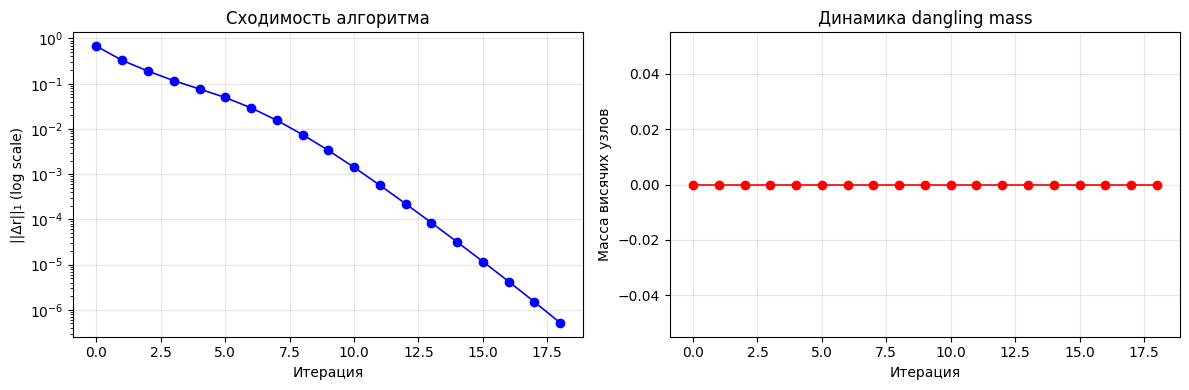

In [10]:
if A_fb is not None:
    print("🚀 Запуск PageRank с обработкой висячих узлов...")
    start = time.time()
    r_fb, hist_fb = pagerank_with_dangling(A_fb, verbose=True)
    elapsed = time.time() - start

    print(f"\n{'='*60}")
    print(f"Вычисление завершено за {elapsed:.2f} сек")
    print(f"   Итераций до сходимости: {hist_fb['iters']}")
    print(f"{'='*60}")

    # Топ-10 наиболее важных узлов по PageRank
    print("\nТоп-10 узлов по значению PageRank:")
    indices = np.array([i for i in range(r_fb.size)])
    values = np.array([r_fb[i].value for i in indices])
    top_k = np.argsort(values)[-10:][::-1]

    for rank, idx in enumerate(top_k, 1):
        print(f"  {rank:2d}. Node {idx:5d}: {values[idx]:.6f}")

    # Визуализация сходимости и массы висячих узлов
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.semilogy(hist_fb['rdiff'], 'b-o', linewidth=1.2)
    plt.xlabel('Итерация')
    plt.ylabel('||Δr||₁ (log scale)')
    plt.title('Сходимость алгоритма')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(hist_fb['dangling_mass'], 'r-o', linewidth=1.2)
    plt.xlabel('Итерация')
    plt.ylabel('Масса висячих узлов')
    plt.title('Динамика dangling mass')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Часть 4: Персонализированный PageRank

In [11]:
def personalized_pagerank(A, personalization=None, damping=0.85,
                         max_iter=100, tol=1e-6, verbose=False):
    import numpy as np
    n = A.nrows

    # Бинарная матрица
    A_bin = A.apply(unary.one).new() if A.dtype != dtypes.UINT8 else A

    # Исходящие степени
    d_out = A_bin.reduce_rowwise(monoid.plus).new()
    d_out_np = d_out.to_dense(fill_value=0)

    # Обратные степени (0 для висячих узлов)
    inv_d_np = np.zeros(n, dtype=np.float64)
    mask_ok = d_out_np > 0
    inv_d_np[mask_ok] = 1.0 / d_out_np[mask_ok]

    # Маска висячих узлов
    mask_dang_np = (d_out_np == 0)

    # Вектор персонализации
    if personalization is None:
        v_np = np.ones(n) / n
    elif isinstance(personalization, dict):
        v_np = np.zeros(n)
        for k, val in personalization.items():
            v_np[k] = val
    else:
        v_np = personalization.to_dense(fill_value=0)
    v_np = v_np / v_np.sum()  # Нормализация

    # Инициализация
    r_np = np.ones(n) / n
    history = {'rdiff': [], 'iters': 0}

    for i in range(max_iter):
        t_np = r_np.copy()

        # w = t ./ d_out (корректно через NumPy)
        w_np = t_np * inv_d_np

        # Графовое распространение через GraphBLAS (самая тяжёлая операция)
        w_vec = Vector.from_dense(w_np, dtype=dtypes.FP64)
        r_np = A_bin.T.mxv(w_vec, semiring.plus_times).to_dense(fill_value=0)

        # Масса висячих узлов
        dangling_mass = t_np[mask_dang_np].sum() if mask_dang_np.any() else 0.0

        # Обновление с телепортацией
        r_np = damping * r_np + (1.0 - damping) * v_np + damping * dangling_mass / n

        # Проверка сходимости
        rdiff = np.abs(t_np - r_np).sum()
        history['rdiff'].append(rdiff)
        history['iters'] = i + 1

        cur_sum = r_np.sum()
        if verbose and i % 10 == 0:
            print(f"Iter {i:3d}: rdiff={rdiff:.2e}, sum_r={cur_sum:.6f}")

        if rdiff < tol:
            if verbose: print(f"Сходимость на итерации {i+1}")
            break

    # Возврат в формате GraphBLAS
    r = Vector.from_dense(r_np, dtype=dtypes.FP64)
    return r, history

### Пример: Поиск узлов, близких к заданному (локальный PageRank)

In [12]:
if A_fb is not None:
    d_out_fb = A_fb.reduce_rowwise(monoid.plus).new()
    seed_node = int(d_out_fb.to_dense(fill_value=0).argmax())

    personalization = Vector(dtypes.FP64, A_fb.nrows)
    personalization[seed_node] << 1.0

    print(f"Персонализированный PageRank (узел {seed_node})")
    r_pers, hist_pers = personalized_pagerank(
        A_fb.T,  # Транспонирование обязательно для корректной ориентации SNAP-графов
        personalization=personalization,
        verbose=True
    )

    print(f"\nТоп-10 ближайших узлов:")
    vals = np.array([r_pers[i].value for i in range(r_pers.size)])
    top = np.argsort(vals)[::-1][:10]
    for rank, idx in enumerate(top, 1):
        print(f"  {rank:2d}. Node {idx:5d}: {vals[idx]:.6f}")

    print(f"\nИтоговая сумма рангов: {r_pers.reduce(monoid.plus).value:.6f} (должно быть ≈ 1.0)")

Персонализированный PageRank (узел 352)
Iter   0: rdiff=1.04e+00, sum_r=1.000000
Iter  10: rdiff=7.43e-03, sum_r=1.000000
Iter  20: rdiff=7.94e-05, sum_r=1.000000
Iter  30: rdiff=9.02e-07, sum_r=1.000000
Сходимость на итерации 31

Топ-10 ближайших узлов:
   1. Node   352: 0.156877
   2. Node     0: 0.089986
   3. Node   107: 0.054346
   4. Node    58: 0.042897
   5. Node   348: 0.023312
   6. Node   951: 0.021746
   7. Node   350: 0.020719
   8. Node  1063: 0.020175
   9. Node   136: 0.019942
  10. Node   371: 0.019939

Итоговая сумма рангов: 1.000000 (должно быть ≈ 1.0)


## Часть 5: Анализ влияния параметра демпфирования β

In [13]:
def analyze_damping_factor(A, betas=[0.80, 0.85, 0.90, 0.95], max_iter=100):
    """
    Исследует влияние коэффициента демпфирования β на результаты PageRank.

    Parameters:
    -----------
    A : gb.Matrix - матрица смежности графа
    betas : list - список значений β для анализа
    max_iter : int - максимальное число итераций для каждого запуска

    Returns:
    --------
    results : dict - словарь с результатами для каждого β:
        {beta: {'r': Vector, 'hist': dict, 'iters': int}}
    """
    results = {}

    for beta in betas:
        print(f"\nβ = {beta:.2f}:")
        r, hist = pagerank_with_dangling(A, damping=beta, max_iter=max_iter)
        results[beta] = {'r': r, 'hist': hist, 'iters': hist['iters']}
        print(f"   Итераций до сходимости: {hist['iters']}")
        print(f"   Финальное rdiff: {hist['rdiff'][-1]:.2e}")

    return results

Анализ влияния параметра демпфирования β...

β = 0.80:
   Итераций до сходимости: 18
   Финальное rdiff: 5.03e-07

β = 0.85:
   Итераций до сходимости: 19
   Финальное rdiff: 5.15e-07

β = 0.90:
   Итераций до сходимости: 20
   Финальное rdiff: 5.37e-07

β = 0.95:
   Итераций до сходимости: 21
   Финальное rdiff: 5.67e-07


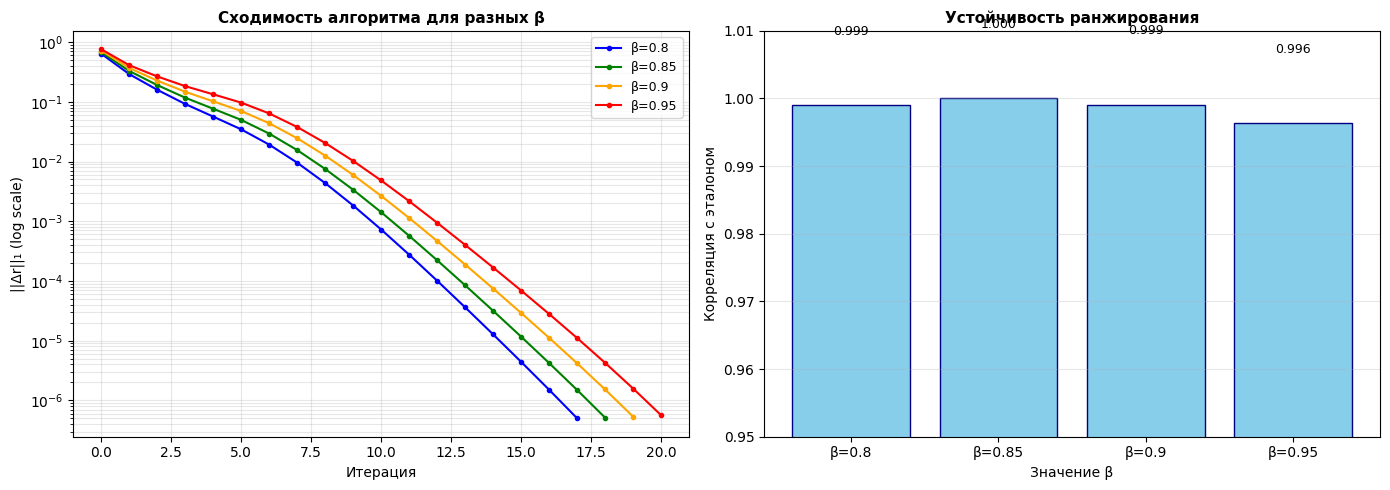


Статистика сходимости:
   β=0.80: 18 итераций
   β=0.85: 19 итераций
   β=0.90: 20 итераций
   β=0.95: 21 итераций


In [14]:
if A_fb is not None and A_fb.nrows < 10000:  # Только для небольших графов для скорости
    print("Анализ влияния параметра демпфирования β...")
    damping_results = analyze_damping_factor(A_fb)

    # Визуализация результатов анализа β
    plt.figure(figsize=(14, 5))

    # График 1: Сходимость для разных значений β
    plt.subplot(1, 2, 1)
    colors = ['blue', 'green', 'orange', 'red']
    for (beta, data), color in zip(damping_results.items(), colors):
        plt.semilogy(data['hist']['rdiff'], color=color, label=f'β={beta}',
                    linewidth=1.5, marker='o', markersize=3)
    plt.xlabel('Итерация', fontsize=10)
    plt.ylabel('||Δr||₁ (log scale)', fontsize=10)
    plt.title('Сходимость алгоритма для разных β', fontsize=11, fontweight='bold')
    plt.legend(fontsize=9)
    plt.grid(True, alpha=0.3, which='both')

    # График 2: Корреляция ранжирований между разными β (относительно β=0.85)
    plt.subplot(1, 2, 2)
    betas = list(damping_results.keys())
    r_ref = damping_results[0.85]['r'] if 0.85 in damping_results else list(damping_results.values())[0]['r']

    correlations = []
    beta_labels = []

    for beta in betas:
        r_curr = damping_results[beta]['r']
        vals_ref = np.array([r_ref[j].value for j in range(r_ref.size)])
        vals_curr = np.array([r_curr[j].value for j in range(r_curr.size)])
        corr = np.corrcoef(vals_ref, vals_curr)[0, 1]
        correlations.append(corr)
        beta_labels.append(f'β={beta}')

    bars = plt.bar(beta_labels, correlations, color='skyblue', edgecolor='navy')
    for bar, corr in zip(bars, correlations):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{corr:.3f}', ha='center', va='bottom', fontsize=9)

    plt.xlabel('Значение β', fontsize=10)
    plt.ylabel('Корреляция с эталоном', fontsize=10)
    plt.title('Устойчивость ранжирования', fontsize=11, fontweight='bold')
    plt.ylim(0.95, 1.01)
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Вывод статистики по итерациям сходимости
    print(f"\nСтатистика сходимости:")
    for beta in betas:
        iters = damping_results[beta]['iters']
        print(f"   β={beta:.2f}: {iters} итераций")

## Часть 6: Сравнение производительности: GraphBLAS vs NetworkX

In [18]:
def benchmark_pagerank_implementations(A, max_iter=100, tol=1e-6):
    """
    Сравнивает производительность реализаций PageRank в GraphBLAS и NetworkX.

    Parameters:
    -----------
    A : gb.Matrix - матрица смежности в формате GraphBLAS
    max_iter : int - максимальное число итераций для обоих алгоритмов
    tol : float - порог сходимости для обоих алгоритмов

    Returns:
    --------
    results : dict - результаты бенчмарка:
        {
            'graphblas': {'time': float, 'iters': int},
            'networkx': {'time': float},
            'max_diff': float (если граф небольшой)
        }
    """
    results = {}

    # === GraphBLAS версия ===
    print("GraphBLAS PageRank...")
    start = time.time()
    r_gb, hist_gb = pagerank_with_dangling(A, max_iter=max_iter, tol=tol)
    time_gb = time.time() - start
    results['graphblas'] = {'time': time_gb, 'iters': hist_gb['iters']}
    print(f"   Время: {time_gb*1000:.2f} мс, Итераций: {hist_gb['iters']}")

    # === NetworkX версия ===
    print("NetworkX PageRank...")
    G_nx = gb.io.to_networkx(A)
    start = time.time()
    pr_nx = nx.pagerank(G_nx, max_iter=max_iter, tol=tol)
    time_nx = time.time() - start
    results['networkx'] = {'time': time_nx}
    print(f"   Время: {time_nx*1000:.2f} мс")

    # === Проверка точности (только для небольших графов) ===
    if A.nrows <= 1000:
        values_gb = np.array([r_gb[i].value for i in range(r_gb.size)])
        values_nx = np.array([pr_nx[i] for i in range(len(pr_nx))])
        max_diff = np.max(np.abs(values_gb - values_nx))
        mean_diff = np.mean(np.abs(values_gb - values_nx))
        print(f"   Макс. разница: {max_diff:.2e}")
        print(f"   Сред. разница: {mean_diff:.2e}")
        results['max_diff'] = max_diff
        results['mean_diff'] = mean_diff

    return results

In [19]:
if A_fb is not None and A_fb.nrows < 5000:
    print("Бенчмарк: GraphBLAS vs NetworkX")
    print("=" * 60)
    perf_results = benchmark_pagerank_implementations(A_fb)

Бенчмарк: GraphBLAS vs NetworkX
GraphBLAS PageRank...
   Время: 31.98 мс, Итераций: 19
NetworkX PageRank...
   Время: 93.89 мс


## 📚 Дополнительные материалы и оптимизации

### Полезные ресурсы:
1. [GraphBLAS Specification](https://graphblas.org/docs/) — официальная спецификация  
2. [SNAP Datasets](https://snap.stanford.edu/data/) — коллекция реальных графов  
3. [LAGraph Library](https://github.com/GraphBLAS/LAGraph) — готовые алгоритмы на GraphBLAS  
4. [Python-GraphBLAS Docs](https://graphblas.org/python/) — документация по Python API  

### Оптимизации для больших графов:
- **Блочная обработка**: `gb.Matrix.ss.split()` для работы с подматрицами  
- **Форматы хранения**: `csr` для быстрого доступа по строкам, `csc` для по столбцам  
- **Типы данных**: `FP32` вместо `FP64` для экономии памяти и ускорения  
- **Параллелизм**: настройка `blocksize` и использование OpenMP в backend  
- **Кэширование**: сохранение промежуточных результатов в диск для повторного использования  

### Контрольные вопросы для самопроверки:
1. Почему висячие узлы требуют специальной обработки в PageRank? Что происходит, если их игнорировать?  
2. Как параметр β влияет на "глобальность" ранжирования? Что происходит при β→1 и β→0?  
3. В чём преимущество GraphBLAS перед NetworkX для больших разреженных графов?  
4. Как можно адаптировать PageRank для взвешенных графов? Как интерпретировать веса рёбер?  
5. Почему алгоритм Power Iteration сходится для стохастических матриц? Какие условия необходимы?  
6. Как оценить сложность одной итерации PageRank в терминах |V| и |E|?  

### Расширенные темы (для углублённого изучения):
- **Approximate PageRank**: алгоритмы с гарантированной точностью и меньшей сложностью  
- **Dynamic PageRank**: поддержание рангов при потоковом обновлении графа  
- **Multi-GPU PageRank**: распределение вычислений между несколькими GPU  
- **Personalization at scale**: эффективная персонализация для миллионов пользователей  

## ✅ Заключение

В этом практическом занятии мы:

✅ Реализовали базовый PageRank с использованием GraphBLAS и Power Iteration  
✅ Добавили корректную обработку висячих узлов (dangling nodes)  
✅ Реализовали персонализированный PageRank для локального ранжирования  
✅ Проанализировали влияние параметра демпфирования β на сходимость и результаты  
✅ Сравнили производительность GraphBLAS с NetworkX на реальных данных  
✅ Подготовили основу для масштабирования на графы с миллионами узлов  

### 🔑 Ключевой вывод:

**GraphBLAS обеспечивает высокую производительность за счёт:**
- Оптимизированных операций с разреженными матрицами (CSR/CSC форматы)  
- Минимальных накладных расходов на абстракции (низкоуровневый доступ)  
- Возможности тонкой настройки под архитектуру (blocksize, параллелизм)  
- Прямой работы с линейной алгеброй без лишних преобразований данных